a. Buscar y cargar un dataset

b. Limpiar datos

Justificar porque en este contexto no tiene sentido hacer la limpieza como segundo paso

c.Detectar:
Outliers
Correlaciones

d.Limpiar datos

e.Agregar un feature o columna nueva


# a. Buscar y cargar un dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pizza_sales.csv")

# b. Limpiar datos

No tiene sentido empezar limpiando los datos, ya que antes necesitamos hacer un overview inicial para ver con que datos nos encontramos

# 1. Overview Inicial(Entender que datos vamos a trabajar)

In [2]:
df.shape

(48620, 12)

el dataset tiene 48620 filas y 12 columnas

In [3]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  float64
 1   order_id           48620 non-null  float64
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  float64
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(5), object(7)
memory usage: 4.5+ MB


In [5]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


# 2. Data cleaning (Limpieza de datos)

In [6]:
df.isnull().sum()

,0
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


en este caso, no hay ningun dato nulo, por lo que se omite la limpieza

In [7]:
df.duplicated().sum()

np.int64(0)

tampoco hay datos duplicados

order_date esta puesto como OBJECT, por lo que hay que pasarlo a DATE

In [8]:
df['order_date'] = df['order_date'].str.replace('-', '/')

ahora todas las fechas si son consistentes!

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [10]:
type(df['order_time'].iloc[0]) #trae el tipo del primero

str

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  float64       
 1   order_id           48620 non-null  float64       
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  float64       
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(6)
memory usage: 4.5+ MB


order_time ya  esta como datetime.time pero en info aparece como objeto

In [12]:
df['pizza_size'].value_counts()

,count
pizza_size,
L,18526
M,15385
S,14137
XL,544
XXL,28


In [13]:
df['pizza_size'] = df['pizza_size'].replace({
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large',
    'XL': 'Extra Large',
    'XXL': 'Extra Extra Large'
})

In [14]:
df['pizza_size'].value_counts()

,count
pizza_size,
Large,18526
Medium,15385
Small,14137
Extra Large,544
Extra Extra Large,28


# C. Detección de Outliers

In [15]:
df['total_price'].describe()

,total_price
count,48620.000000
mean,16.821474
std,4.437398
min,9.750000
25%,12.750000
50%,16.500000
75%,20.500000
max,83.000000


se ve que el mayor valor es 83

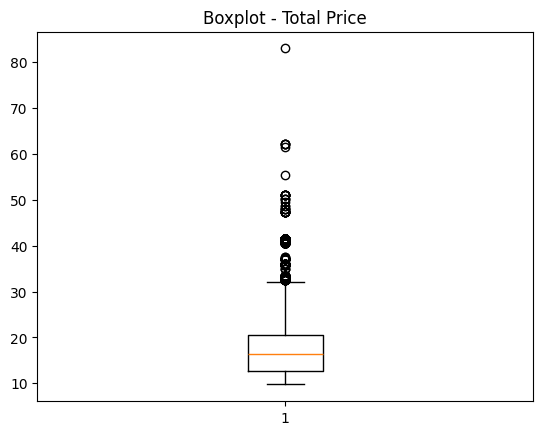

In [16]:
plt.boxplot(df['total_price'])
plt.title('Boxplot - Total Price')
plt.show()

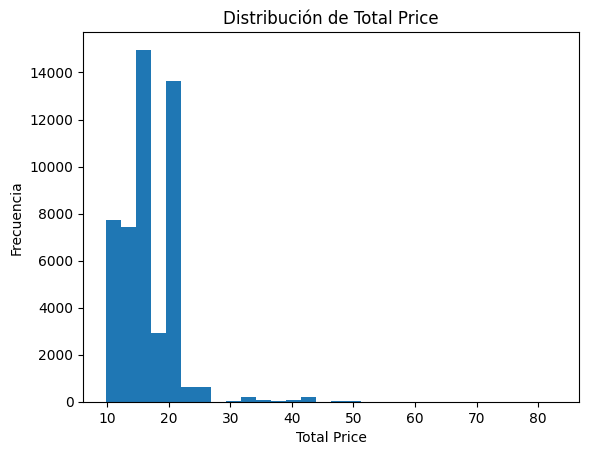

In [17]:
plt.hist(df['total_price'], bins=30)
plt.title('Distribución de Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frecuencia')
plt.show()

In [18]:
Q1 = df['total_price'].quantile(0.25)
Q3 = df['total_price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['total_price'] < Q1 - 1.5*IQR) |
              (df['total_price'] > Q3 + 1.5*IQR)]

len(outliers)

613

In [19]:
outliers.sort_values(by='total_price', ascending=False).head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
35496,35497.0,15674.0,cali_ckn_l,4.0,2015-09-19,14:16:35,20.75,83.00,Large,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ...",The California Chicken Pizza
183,184.0,78.0,spicy_ital_l,3.0,2015-01-02,12:28:14,20.75,62.25,Large,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ...",The Spicy Italian Pizza
18317,18318.0,8040.0,thai_ckn_l,3.0,2015-05-15,14:13:27,20.75,62.25,Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
37638,37639.0,16619.0,prsc_argla_l,3.0,2015-10-08,12:19:53,20.75,62.25,Large,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza
38819,38820.0,17112.0,bbq_ckn_l,3.0,2015-10-17,12:56:31,20.75,62.25,Large,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


los valores atipicos de total_price corresponden a pedidos con mayor cantidad de productos, que incrementa el valor total de la orden, por lo que no son errores.

In [20]:
df[['quantity', 'total_price']].corr()

,quantity,total_price
quantity,1.000000,0.541926
total_price,0.541926,1.000000


tiene correlacion positiva moderada, lo que indica a mayor cant de productos, mayor precio total.

In [21]:
df[['unit_price', 'total_price']].corr()

,unit_price,total_price
unit_price,1.000000,0.836087
total_price,0.836087,1.000000


correlacion fuerte, a mayor precio unitario, mayor precio total.

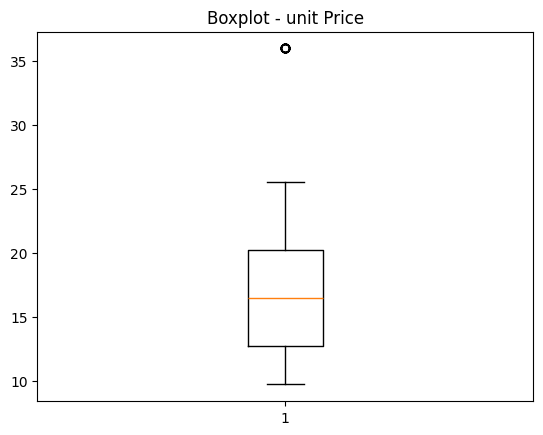

In [22]:
plt.boxplot(df['unit_price'])
plt.title('Boxplot - unit Price')
plt.show()

se puede observar un valor atipico de una pizza con precio unitario mayor a 35.

In [23]:
df.sort_values(by='unit_price', ascending=False).head(1)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
41182,41183.0,18139.0,the_greek_xxl,1.0,2015-11-05,20:28:52,35.95,35.95,Extra Extra Large,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",The Greek Pizza


In [24]:
df.groupby('pizza_size')['unit_price'].mean()

,unit_price
pizza_size,
Extra Extra Large,35.950000
Extra Large,25.500000
Large,19.802553
Medium,15.951219
Small,12.364328


el valor atipico de 35 dolares por la pizza inicial esta bien, ya que el tamaño es extra extra large y como se puede ver la correlacion, a mayor tamaño de pizza, mayor precio.

# e. Nueva columna

In [26]:
df['order_datetime'] = pd.to_datetime(
    df['order_date'].astype(str) + ' ' + df['order_time'].astype(str)
)

In [29]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_datetime
0,1.0,1.0,hawaiian_m,1.0,2015-01-01,11:38:36,13.25,13.25,Medium,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,2015-01-01 11:38:36
1,2.0,2.0,classic_dlx_m,1.0,2015-01-01,11:57:40,16.00,16.00,Medium,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015-01-01 11:57:40
2,3.0,2.0,five_cheese_l,1.0,2015-01-01,11:57:40,18.50,18.50,Large,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,2015-01-01 11:57:40
3,4.0,2.0,ital_supr_l,1.0,2015-01-01,11:57:40,20.75,20.75,Large,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,2015-01-01 11:57:40
4,5.0,2.0,mexicana_m,1.0,2015-01-01,11:57:40,16.00,16.00,Medium,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,2015-01-01 11:57:40


corroboro que la ultima columna es la creada